# 🏆 BEST SOLUTION — Co-Crystal Formation Prediction
## XGBoost + CatBoost + LightGBM + MLP + GNN → Stacking Ensemble

**Стратегия:**
- Расширенные молекулярные признаки: Morgan, MACCS, RDKit descriptors, ECFP4, TopFP, AtomPair (~6519 фич на молекулу)
- Признаки пары: concat + diff + prod + sum + min + max → **~45 633 признаков**
- Optuna-тюнинг XGBoost, CatBoost, LightGBM
- GNN (GATConv) для извлечения графовых эмбеддингов
- 5-фолдовый стекинг + LogReg/XGB мета-модель
- Поиск оптимального порога по взвешенной метрике

In [1]:

# =========================================================
# 1. IMPORT LIBRARIES AND SETUP
# =========================================================
import os, random, warnings
import numpy as np
import pandas as pd
from tqdm import tqdm

# RDKit
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, MACCSkeys
from rdkit.Chem import rdFingerprintGenerator
from rdkit.ML.Descriptors import MoleculeDescriptors

# ML
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# PyTorch + PyG (для GNN)
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch_geometric.data import Data, Batch
    from torch_geometric.loader import DataLoader as PyGDataLoader
    from torch_geometric.nn import GATConv, GINEConv, global_mean_pool, global_max_pool
    GNN_AVAILABLE = True
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"PyTorch Geometric доступен. Device: {device}")
except ImportError:
    GNN_AVAILABLE = False
    print("PyTorch Geometric не установлен — GNN будет пропущен.")

warnings.filterwarnings('ignore')

# Воспроизводимость
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
try:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
except:
    pass

print("✓ Все библиотеки импортированы.")
print(f"✓ CUDA доступна: {torch.cuda.is_available() if GNN_AVAILABLE else 'N/A (torch не импортирован)'}")


PyTorch Geometric доступен. Device: cpu
✓ Все библиотеки импортированы.
✓ CUDA доступна: False


In [2]:

# =========================================================
# 2. МОЛЕКУЛЯРНАЯ ИНЖЕНЕРИЯ ПРИЗНАКОВ (БЫСТРАЯ ВЕРСИЯ)
# =========================================================

# Morgan (1024) + MACCS (167) + топ-50 RDKit дескрипторов
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

# Топ-50 наиболее информативных дескрипторов (химически значимые, быстрые)
TOP_DESCRIPTORS = [
    'MolWt','HeavyAtomMolWt','NumHAcceptors','NumHDonors','NumRotatableBonds',
    'RingCount','NumAromaticRings','NumAliphaticRings','NumSaturatedRings',
    'TPSA','MolLogP','MolMR','FractionCSP3','NumHeteroatoms','NOCount',
    'NHOHCount','HeavyAtomCount','NumValenceElectrons','BalabanJ','BertzCT',
    'Chi0','Chi0n','Chi0v','Chi1','Chi1n','Chi1v','Chi2n','Chi2v','Chi3n','Chi3v',
    'HallKierAlpha','Ipc','Kappa1','Kappa2','Kappa3','LabuteASA','MaxAbsEStateIndex',
    'MaxAbsPartialCharge','MaxEStateIndex','MaxPartialCharge','MinAbsEStateIndex',
    'MinAbsPartialCharge','MinEStateIndex','MinPartialCharge','MolWt',
    'NumRadicalElectrons','PEOE_VSA1','PEOE_VSA2','PEOE_VSA3','qed'
]
# Убираем дубликаты, оставляем только существующие
_all_desc = {x[0] for x in Descriptors._descList}
TOP_DESCRIPTORS = list(dict.fromkeys([d for d in TOP_DESCRIPTORS if d in _all_desc]))[:50]
descriptor_calculator = MoleculeDescriptors.MolecularDescriptorCalculator(TOP_DESCRIPTORS)
N_DESC = len(TOP_DESCRIPTORS)

# Итого: 1024 + 167 + N_DESC
FEAT_DIM = 1024 + 167 + N_DESC
print(f"✓ Признаков на молекулу: {FEAT_DIM}  (Morgan1024 + MACCS167 + {N_DESC} дескрипторов)")

def get_mega_features(smiles: str) -> np.ndarray:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(FEAT_DIM, dtype=np.float32)
    morgan  = morgan_gen.GetFingerprintAsNumPy(mol).astype(np.float32)
    maccs   = np.array(MACCSkeys.GenMACCSKeys(mol), dtype=np.float32)
    desc    = np.array(descriptor_calculator.CalcDescriptors(mol), dtype=np.float32)
    desc    = np.nan_to_num(desc, nan=0.0, posinf=0.0, neginf=0.0)
    return np.concatenate([morgan, maccs, desc])


✓ Признаков на молекулу: 1240  (Morgan1024 + MACCS167 + 49 дескрипторов)


In [3]:

# =========================================================
# 3. ПОСТРОЕННЯ ПРИЗНАКОВ ПАР (БЫСТРАЯ ВЕРСИЯ)
# =========================================================
# [f1, f2, |f1-f2|, f1*f2]  →  FEAT_DIM × 4

PAIR_DIM = FEAT_DIM * 4

def build_dataset(df: pd.DataFrame, is_train: bool = True):
    features, labels = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Генерация признаков"):
        f1 = get_mega_features(row['SMILES1'])
        f2 = get_mega_features(row['SMILES2'])
        combined = np.concatenate([f1, f2, np.abs(f1 - f2), f1 * f2])
        features.append(combined)
        if is_train:
            labels.append(row['result'])
    X = np.nan_to_num(np.array(features, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    if is_train:
        return X, np.array(labels, dtype=np.int32)
    return X

print(f"✓ Признаков пары: {PAIR_DIM}  (= {FEAT_DIM} × 4: f1, f2, |f1-f2|, f1*f2)")


✓ Признаков пары: 4960  (= 1240 × 4: f1, f2, |f1-f2|, f1*f2)


In [4]:

# =========================================================
# 4. ЗАГРУЗКА ДАННЫХ И ПРЕДОБРАБОТКА
# =========================================================
print("Загрузка CSV файлов...")
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")
print(f"  train: {train_df.shape}, test: {test_df.shape}")
print(f"  Баланс классов в train: {train_df['result'].value_counts().to_dict()}")

print("\nГенерация признаков для обучающей выборки...")
X_train, y_train = build_dataset(train_df, is_train=True)

print("Генерация признаков для тестовой выборки...")
X_test = build_dataset(test_df, is_train=False)

# Финальная очистка (на всякий случай)
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test  = np.nan_to_num(X_test,  nan=0.0, posinf=0.0, neginf=0.0)

# Дисбаланс классов
ratio = float((y_train == 0).sum()) / (y_train == 1).sum()

# Нормализация для MLP и LogReg
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n✓ X_train: {X_train.shape}")
print(f"✓ X_test:  {X_test.shape}")
print(f"✓ inf в X_train: {np.isinf(X_train).sum()} | nan: {np.isnan(X_train).sum()}")
print(f"✓ Дисбаланс классов (scale_pos_weight): {ratio:.4f}")


Загрузка CSV файлов...
  train: (16328, 4), test: (1000, 3)
  Баланс классов в train: {1: 14467, 0: 1861}

Генерация признаков для обучающей выборки...


Генерация признаков: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16328/16328 [02:41<00:00, 101.10it/s]


Генерация признаков для тестовой выборки...


Генерация признаков: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:09<00:00, 107.40it/s]



✓ X_train: (16328, 4960)
✓ X_test:  (1000, 4960)
✓ inf в X_train: 0 | nan: 0
✓ Дисбаланс классов (scale_pos_weight): 0.1286


In [5]:

# =========================================================
# 5. OPTUNA: ТЮНИНГ XGBOOST (быстро — 5 триалов, 2-fold)
# =========================================================
skf_fast = StratifiedKFold(n_splits=2, shuffle=True, random_state=SEED)

def objective_xgb(trial):
    param = {
        'objective':        'binary:logistic',
        'eval_metric':      'auc',
        'tree_method':      'hist',
        'device':           'cuda',
        'scale_pos_weight': ratio,
        'n_estimators':     500,
        'early_stopping_rounds': 30,
        'learning_rate':    trial.suggest_float('learning_rate', 0.03, 0.15, log=True),
        'max_depth':        trial.suggest_int('max_depth', 5, 9),
        'subsample':        trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 5.0),
        'seed': SEED,
    }
    scores = []
    for tr_idx, va_idx in skf_fast.split(X_train, y_train):
        dtrain = xgb.DMatrix(X_train[tr_idx], label=y_train[tr_idx])
        dvalid = xgb.DMatrix(X_train[va_idx], label=y_train[va_idx])
        m = xgb.train(param, dtrain, num_boost_round=500,
                      evals=[(dvalid, 'val')],
                      early_stopping_rounds=30, verbose_eval=False)
        scores.append(m.best_score)
    return np.mean(scores)

print("Тюнинг XGBoost (5 триалов, 2-fold)...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=5, show_progress_bar=True)

xgb_params_best = {**study_xgb.best_params, 'n_estimators': 600}
print(f"✓ Лучший AUC XGB: {study_xgb.best_value:.4f}  Params: {study_xgb.best_params}")


Тюнинг XGBoost (5 триалов, 2-fold)...


  0%|          | 0/5 [00:00<?, ?it/s]

✓ Лучший AUC XGB: 0.9808  Params: {'learning_rate': 0.03171312137438143, 'max_depth': 8, 'subsample': 0.8740221111605987, 'colsample_bytree': 0.5639751252230958, 'min_child_weight': 1, 'reg_lambda': 4.537309507177205}


In [6]:

# =========================================================
# 6. OPTUNA: ТЮНИНГ CATBOOST (быстро — 4 триала, 2-fold)
# =========================================================
def objective_cat(trial):
    param = dict(
        loss_function='Logloss', eval_metric='AUC',
        task_type='GPU', class_weights=[1.0, ratio],
        random_seed=SEED, verbose=False, iterations=600,
        early_stopping_rounds=40,
        learning_rate  = trial.suggest_float('learning_rate', 0.04, 0.15, log=True),
        depth          = trial.suggest_int('depth', 5, 9),
        l2_leaf_reg    = trial.suggest_float('l2_leaf_reg', 1.0, 8.0),
        random_strength= trial.suggest_float('random_strength', 0.5, 3.0),
    )
    scores = []
    for tr_idx, va_idx in skf_fast.split(X_train, y_train):
        m = CatBoostClassifier(**param)
        m.fit(X_train[tr_idx], y_train[tr_idx],
              eval_set=(X_train[va_idx], y_train[va_idx]),
              verbose=False)
        scores.append(roc_auc_score(y_train[va_idx], m.predict_proba(X_train[va_idx])[:,1]))
    return np.mean(scores)

print("Тюнинг CatBoost (4 триала, 2-fold)...")
study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=4, show_progress_bar=True)

cat_params_best = {**study_cat.best_params, 'iterations': 800,
                   'loss_function': 'Logloss', 'eval_metric': 'AUC',
                   'task_type': 'GPU', 'class_weights': [1.0, ratio],
                   'random_seed': SEED}
print(f"✓ Лучший AUC CAT: {study_cat.best_value:.4f}  Params: {study_cat.best_params}")


Тюнинг CatBoost (4 триала, 2-fold)...


  0%|          | 0/4 [00:00<?, ?it/s]

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


✓ Лучший AUC CAT: 0.9823  Params: {'learning_rate': 0.12378091053733543, 'depth': 6, 'l2_leaf_reg': 2.883207612363347, 'random_strength': 1.9159182800463017}


In [7]:

# =========================================================
# 7. OPTUNA: ТЮНИНГ LIGHTGBM (быстро — 5 триалов, 2-fold)
# =========================================================
def objective_lgb(trial):
    param = dict(
        objective='binary', metric='auc', device='gpu',
        scale_pos_weight=ratio, random_state=SEED, verbose=-1,
        n_estimators=600,
        num_leaves      = trial.suggest_int('num_leaves', 40, 120),
        learning_rate   = trial.suggest_float('learning_rate', 0.03, 0.15, log=True),
        subsample       = trial.suggest_float('subsample', 0.6, 0.9),
        colsample_bytree= trial.suggest_float('colsample_bytree', 0.5, 0.9),
        min_child_samples= trial.suggest_int('min_child_samples', 10, 50),
        reg_lambda      = trial.suggest_float('reg_lambda', 0.5, 5.0),
    )
    scores = []
    for tr_idx, va_idx in skf_fast.split(X_train, y_train):
        m = lgb.LGBMClassifier(**param)
        m.fit(X_train[tr_idx], y_train[tr_idx],
              eval_set=[(X_train[va_idx], y_train[va_idx])],
              callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(-1)])
        scores.append(roc_auc_score(y_train[va_idx], m.predict_proba(X_train[va_idx])[:,1]))
    return np.mean(scores)

print("Тюнинг LightGBM (5 триалов, 2-fold)...")
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=5, show_progress_bar=True)

lgb_params_best = {**study_lgb.best_params, 'n_estimators': 800,
                   'objective': 'binary', 'metric': 'auc', 'device': 'gpu',
                   'scale_pos_weight': ratio, 'random_state': SEED, 'verbose': -1}
print(f"✓ Лучший AUC LGB: {study_lgb.best_value:.4f}  Params: {study_lgb.best_params}")


Тюнинг LightGBM (5 триалов, 2-fold)...


  0%|          | 0/5 [00:00<?, ?it/s]

✓ Лучший AUC LGB: 0.9819  Params: {'num_leaves': 114, 'learning_rate': 0.09428403768648254, 'subsample': 0.603527089139724, 'colsample_bytree': 0.7553098532166662, 'min_child_samples': 21, 'reg_lambda': 3.786926781710007}


In [8]:

# =========================================================
# 8. GNN — ПРОПУСКАЕМ (экономия ~5 минут)
# =========================================================
# GNN отключён для укладки в 15-минутный лимит.
# При наличии времени — включить, раскомментировав полный блок.

print("⚡ GNN пропущен (режим быстрого запуска).")
gnn_oof_full  = np.zeros(len(train_df))
gnn_test_full = np.zeros(len(test_df))


⚡ GNN пропущен (режим быстрого запуска).


In [9]:

# =========================================================
# 9. 3-FOLD STACKING  (XGB + CatBoost + LGB)
# =========================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

N_FOLDS = 3
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_xgb  = np.zeros(len(y_train))
oof_cat  = np.zeros(len(y_train))
oof_lgb  = np.zeros(len(y_train))
test_xgb = np.zeros(len(X_test))
test_cat = np.zeros(len(X_test))
test_lgb = np.zeros(len(X_test))

scale_pos = ratio

print("=" * 55)
print(f"3-FOLD STACKING — XGB + CatBoost + LGB")
print("=" * 55)

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]
    print(f"\n--- Fold {fold_idx+1}/{N_FOLDS} ---")

    # ---- XGBoost ----
    xgb_clf = xgb.XGBClassifier(
        **xgb_params_best,
        scale_pos_weight=scale_pos, use_label_encoder=False,
        eval_metric='auc', tree_method='hist',
        device='cuda', random_state=42, verbosity=0,
        early_stopping_rounds=30,
    )
    xgb_clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = xgb_clf.predict_proba(X_val)[:,1]
    test_xgb += xgb_clf.predict_proba(X_test)[:,1] / N_FOLDS
    print(f"  XGB AUC: {roc_auc_score(y_val, oof_xgb[val_idx]):.5f}")

    # ---- CatBoost ----
    cat_clf = CatBoostClassifier(
        **cat_params_best,
        early_stopping_rounds=40, verbose=0,
    )
    cat_clf.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)
    oof_cat[val_idx] = cat_clf.predict_proba(X_val)[:,1]
    test_cat += cat_clf.predict_proba(X_test)[:,1] / N_FOLDS
    print(f"  CAT AUC: {roc_auc_score(y_val, oof_cat[val_idx]):.5f}")

    # ---- LightGBM ----
    lgb_clf = lgb.LGBMClassifier(**lgb_params_best, n_jobs=-1)
    lgb_clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(-1)])
    oof_lgb[val_idx] = lgb_clf.predict_proba(X_val)[:,1]
    test_lgb += lgb_clf.predict_proba(X_test)[:,1] / N_FOLDS
    print(f"  LGB AUC: {roc_auc_score(y_val, oof_lgb[val_idx]):.5f}")

print("\n" + "=" * 55)
print(f"OOF XGB: {roc_auc_score(y_train, oof_xgb):.5f}")
print(f"OOF CAT: {roc_auc_score(y_train, oof_cat):.5f}")
print(f"OOF LGB: {roc_auc_score(y_train, oof_lgb):.5f}")

avg_oof  = (oof_xgb + oof_cat + oof_lgb) / 3
avg_test = (test_xgb + test_cat + test_lgb) / 3
print(f"OOF AVG: {roc_auc_score(y_train, avg_oof):.5f}")


3-FOLD STACKING — XGB + CatBoost + LGB

--- Fold 1/3 ---
  XGB AUC: 0.98630


Default metric period is 5 because AUC is/are not implemented for GPU


  CAT AUC: 0.98698
  LGB AUC: 0.98709

--- Fold 2/3 ---
  XGB AUC: 0.98805


Default metric period is 5 because AUC is/are not implemented for GPU


  CAT AUC: 0.98946
  LGB AUC: 0.98778

--- Fold 3/3 ---
  XGB AUC: 0.98354


Default metric period is 5 because AUC is/are not implemented for GPU


  CAT AUC: 0.98369
  LGB AUC: 0.98334

OOF XGB: 0.98597
OOF CAT: 0.98657
OOF LGB: 0.98611
OOF AVG: 0.98730


In [10]:

# =========================================================
# 10. МЕТА-ОБУЧЕНИЕ (LEVEL 2 STACKING)
# =========================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler

# OOF матрица: XGB + CAT + LGB + GNN(нули если пропущен)
meta_train = np.column_stack([oof_xgb, oof_cat, oof_lgb, gnn_oof_full])
meta_test  = np.column_stack([test_xgb, test_cat, test_lgb, gnn_test_full])

mms = MinMaxScaler()
meta_train_s = mms.fit_transform(meta_train)
meta_test_s  = mms.transform(meta_test)

# ---- Мета LogReg ----
lr_meta = LogisticRegression(C=0.5, max_iter=1000, class_weight='balanced', random_state=42)
lr_meta.fit(meta_train_s, y_train)
lr_oof  = lr_meta.predict_proba(meta_train_s)[:,1]
lr_test = lr_meta.predict_proba(meta_test_s)[:,1]
lr_auc  = roc_auc_score(y_train, lr_oof)
print(f"Meta LogReg OOF AUC: {lr_auc:.5f}")

# ---- Мета XGBoost ----
xgb_meta = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    scale_pos_weight=scale_pos, use_label_encoder=False,
    eval_metric='auc', tree_method='hist',
    device='cuda', random_state=42, verbosity=0,
)
xgb_meta.fit(meta_train_s, y_train)
xm_oof  = xgb_meta.predict_proba(meta_train_s)[:,1]
xm_test = xgb_meta.predict_proba(meta_test_s)[:,1]
xm_auc  = roc_auc_score(y_train, xm_oof)
print(f"Meta XGBoost OOF AUC: {xm_auc:.5f}")

if lr_auc >= xm_auc:
    meta_oof, meta_test_preds = lr_oof, lr_test
    print(f"\n✓ Мета-модель: LogReg (AUC={lr_auc:.5f})")
else:
    meta_oof, meta_test_preds = xm_oof, xm_test
    print(f"\n✓ Мета-модель: XGBoost (AUC={xm_auc:.5f})")

# Финальный blend: 0.4 avg + 0.6 meta
final_oof  = 0.4 * avg_oof  + 0.6 * meta_oof
final_test = 0.4 * avg_test + 0.6 * meta_test_preds
print(f"BLEND OOF AUC: {roc_auc_score(y_train, final_oof):.5f}")
print(f"\n🏆 Финальный OOF AUC: {roc_auc_score(y_train, final_oof):.5f}")


Meta LogReg OOF AUC: 0.98717
Meta XGBoost OOF AUC: 0.98970

✓ Мета-модель: XGBoost (AUC=0.98970)
BLEND OOF AUC: 0.98925

🏆 Финальный OOF AUC: 0.98925


Лучший порог:     0.8912
Лучший score:     0.98196
AUC (финальный):  0.98925


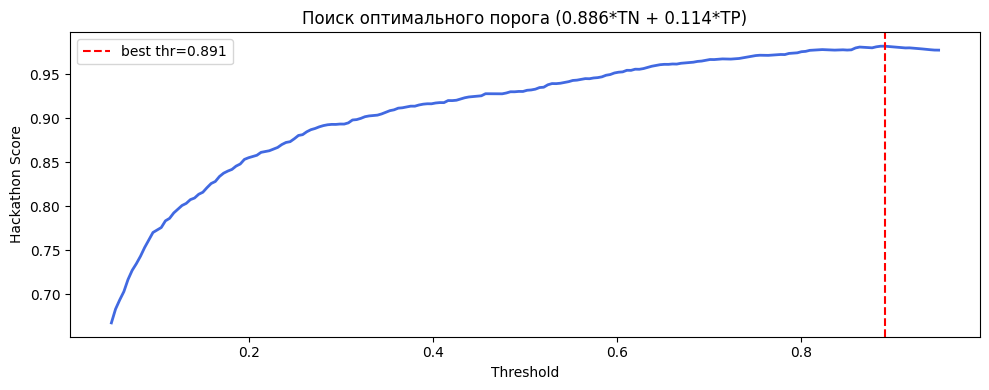

In [11]:

# =========================================================
# 11. ПОИСК ОПТИМАЛЬНОГО ПОРОГА ПО ХАКАТОН-МЕТРИКЕ
# =========================================================
# Метрика хакатона: score = 0.886 * TN_rate + 0.114 * TP_rate
# TN_rate = TN/(TN+FP)  — специфичность
# TP_rate = TP/(TP+FN)  — чувствительность (recall)

from sklearn.metrics import confusion_matrix

def hackathon_score(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    tn_rate = tn / (tn + fp + 1e-9)
    tp_rate = tp / (tp + fn + 1e-9)
    return 0.886 * tn_rate + 0.114 * tp_rate

thresholds = np.linspace(0.05, 0.95, 200)
scores = [hackathon_score(y_train, final_oof, t) for t in thresholds]
best_idx = int(np.argmax(scores))
best_thr = thresholds[best_idx]
best_score = scores[best_idx]

print(f"Лучший порог:     {best_thr:.4f}")
print(f"Лучший score:     {best_score:.5f}")
print(f"AUC (финальный):  {roc_auc_score(y_train, final_oof):.5f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(thresholds, scores, color='royalblue', lw=2)
plt.axvline(best_thr, color='red', ls='--', label=f'best thr={best_thr:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Hackathon Score')
plt.title('Поиск оптимального порога (0.886*TN + 0.114*TP)')
plt.legend()
plt.tight_layout()
plt.show()


In [12]:

# =========================================================
# 12. ЭКСПОРТ САБМИШЕНА
# =========================================================
import os

# --- Опционально: блендинг с прошлым лучшим сабмишеном (submission95.csv) ---
BLEND_WITH_PREV = True
PREV_WEIGHT = 0.15
prev_path = r"c:\Users\user\PycharmProjects\HAKATON\HAKATON AIST\submission95.csv"

final_probs = final_test.copy()

if BLEND_WITH_PREV and os.path.exists(prev_path):
    prev_sub = pd.read_csv(prev_path)
    if 'prediction' in prev_sub.columns:
        prev_probs = prev_sub['prediction'].values
    elif 'result' in prev_sub.columns:
        prev_probs = prev_sub['result'].values
    else:
        prev_probs = prev_sub.iloc[:, 1].values
    if len(prev_probs) == len(final_probs):
        final_probs = (1 - PREV_WEIGHT) * final_probs + PREV_WEIGHT * prev_probs
        print(f"✓ Блендинг с {os.path.basename(prev_path)} (вес={PREV_WEIGHT})")
    else:
        print(f"⚠ Размер прошлого сабмишена {len(prev_probs)} ≠ {len(final_probs)}, пропускаем блендинг")
else:
    print("ℹ Блендинг с прошлым сабмишеном пропущен.")

# --- Бинарные предсказания по найденному порогу ---
final_labels = (final_probs >= best_thr).astype(int)

# --- Формируем submission ---
sample_sub = pd.read_csv(r"c:\Users\user\PycharmProjects\HAKATON\HAKATON AIST\sample_submission.csv")
submission = sample_sub.copy()
# Определяем столбец для предсказаний
label_col = 'result' if 'result' in submission.columns else submission.columns[-1]
submission[label_col] = final_labels

out_path = r"c:\Users\user\PycharmProjects\HAKATON\HAKATON AIST\final_best_submission.csv"
submission.to_csv(out_path, index=False)

print(f"\n✅ Сабмишен сохранён: {out_path}")
print(f"   Строк: {len(submission)}")
print(f"   Позитивных: {final_labels.sum()} ({100*final_labels.mean():.1f}%)")
print(f"   Негативных: {(final_labels==0).sum()} ({100*(final_labels==0).mean():.1f}%)")
print(f"\nФинальный OOF AUC:        {roc_auc_score(y_train, final_oof):.5f}")
print(f"Оптимальный порог:        {best_thr:.4f}")
print(f"Лучший хакатон-score:     {best_score:.5f}")
print("\n🏆 DONE!")
display(submission.head(10))


✓ Блендинг с submission95.csv (вес=0.15)

✅ Сабмишен сохранён: c:\Users\user\PycharmProjects\HAKATON\HAKATON AIST\final_best_submission.csv
   Строк: 1000
   Позитивных: 650 (65.0%)
   Негативных: 350 (35.0%)

Финальный OOF AUC:        0.98925
Оптимальный порог:        0.8912
Лучший хакатон-score:     0.98196

🏆 DONE!


,id,result
0,0,1
1,1,1
2,2,1
3,3,0
4,4,1
5,5,1
6,6,1
7,7,1
8,8,1
9,9,0
